In [1]:
import os
import numpy as np
import pickle
from statsmodels.stats.multitest import fdrcorrection
import scipy.stats as stats
import scipy.io as sio
import matplotlib.pyplot as plt
from nilearn.image import new_img_like
import pandas as pd
import nibabel as nib
import csv
from nilearn import plotting
from nilearn.image import resample_img
from nilearn.image import math_img
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from glob import glob
import nilearn.image as nlimg
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight

from scipy.stats import spearmanr
from tqdm import tqdm
# from rsatoolbox.data.dataset import Dataset
# from rsatoolbox.rdm.calc import calc_rdm
# from rsatoolbox.rdm import RDMs
import seaborn as sns
from sklearn.metrics import pairwise_distances
import copy

In [7]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [8]:
import matplotlib.colors
def RDMcolormapObject(direction=1):
    """
    Returns a matplotlib color map object for RSA and brain plotting
    """
    if direction == 0:
        cs = ['yellow', 'red', 'gray', 'turquoise', 'blue']
    elif direction == 1:
        cs = ['blue', 'turquoise', 'gray', 'red', 'yellow']
    else:
        raise ValueError('Direction needs to be 0 or 1')
    cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", cs)
    return cmap

In [9]:
tmp_image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/nifti/Nt1.img'
# load one image to get the dimensions and make the mask

tmp_img = nib.load(tmp_image_path)

## Create mask for RDMs

### Using subject fMRI data to create mask

    Avoid using subject data that included eyeball voxels. Subjects 4, 5, 10, 11, 15, 16, and 17 fMRI data do not contain eyeball voxels. 

C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16340\3353029201.py:26: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  mask_3d = new_img_like(tmp_img, mask)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\numpy\_core\fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16340\3353029201.py:27: UserWarning: Casting data from int32 to float32
  view = plotting.view_img(mask_3d)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_16340\3353029201.py:27: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might con


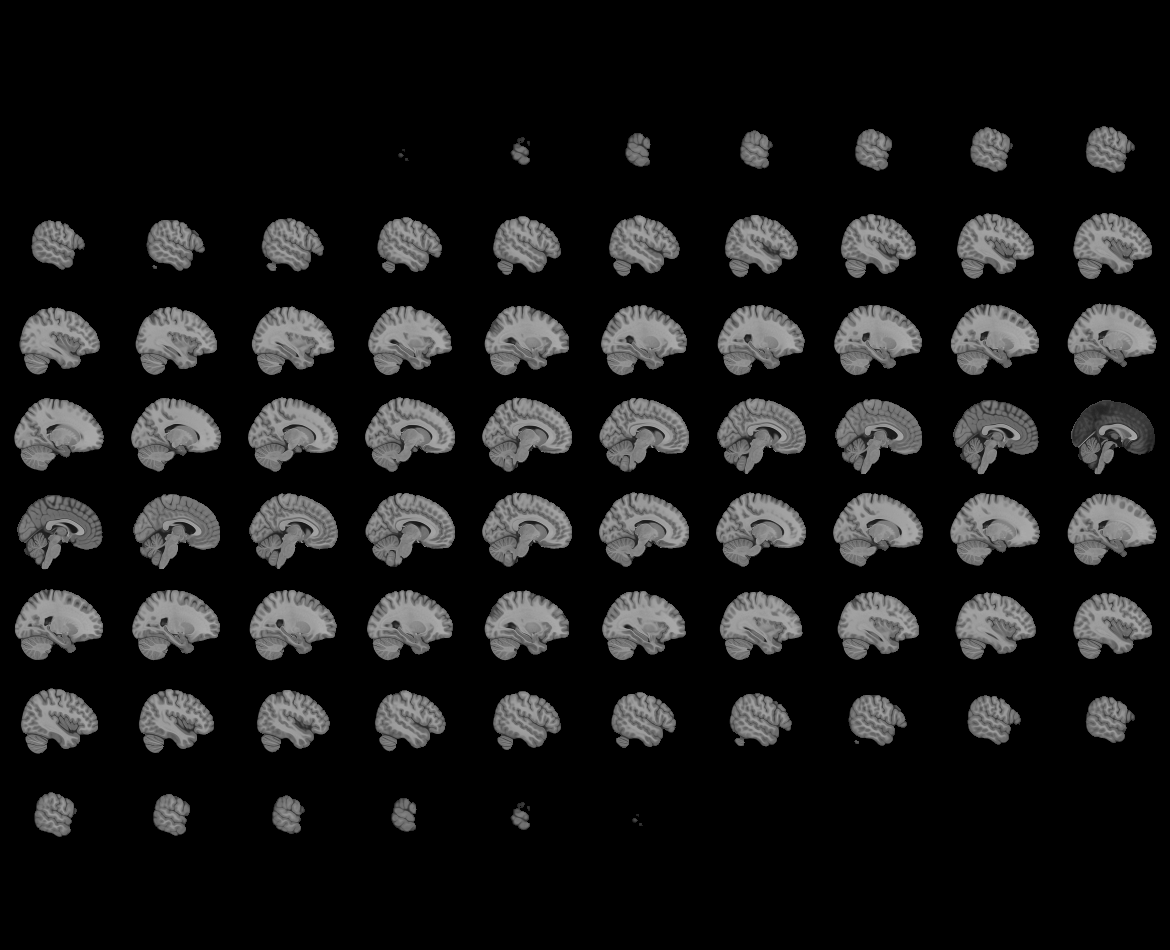
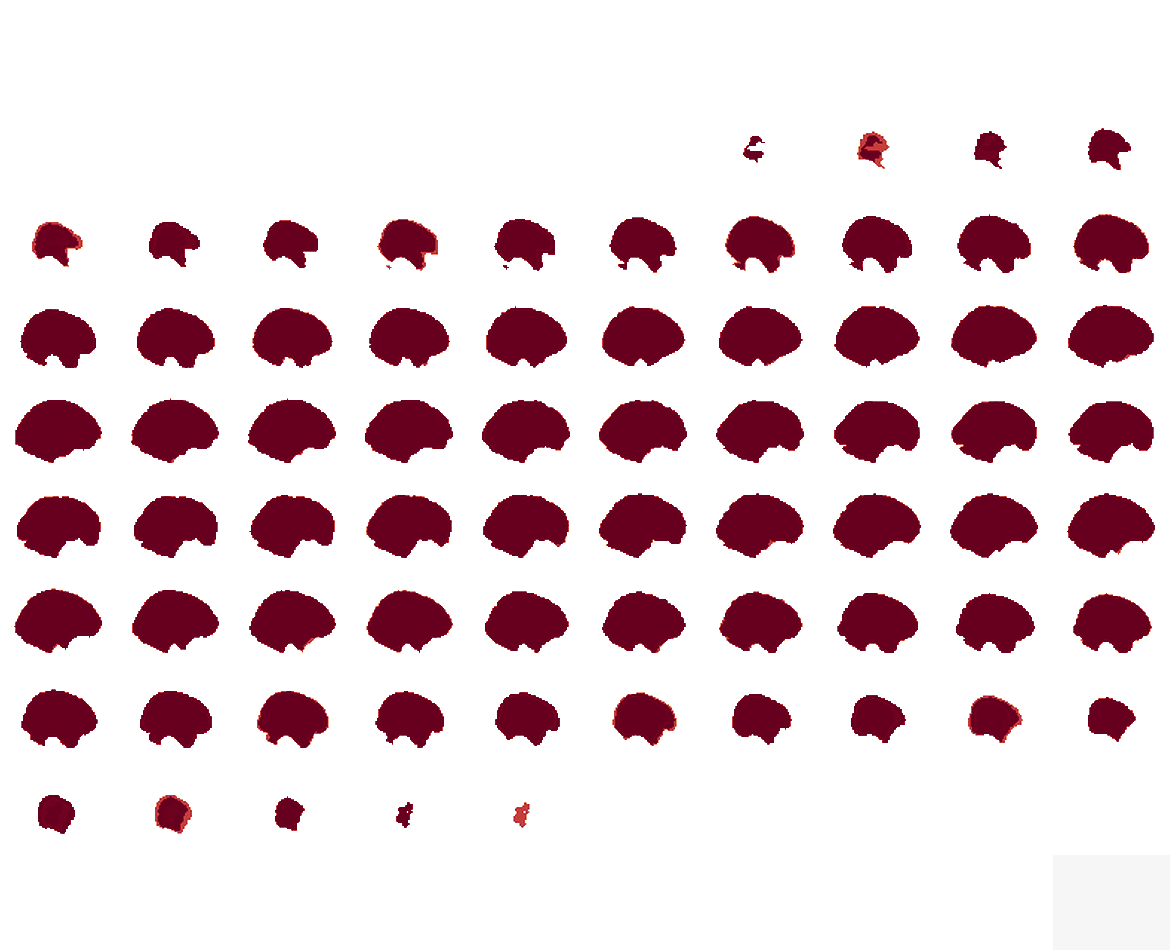

In [11]:
stimuli = ['Pl','Nt','Up']
no_eyeballvoxel_subjects = [4,5,10,11,15,16,17]

sub_mask_list = []
for s, sub in enumerate(no_eyeballvoxel_subjects):

    mask_list = []
    for i, stim in enumerate(stimuli):
        image_path = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/{}{}.mat'.format(stim,sub-1)
        # load one image to get the dimensions and make the mask
        image_file = sio.loadmat(image_path)
        mask_file = image_file['{}'.format(stim)] #(153594, 100)
        mask_list.append(mask_file)

    allmask = np.hstack(mask_list)
    mask_sum = np.sum(allmask, axis = 1)
    sub_mask_list.append(mask_sum)

allsub_mask = np.vstack(sub_mask_list)
allsub_mask_sum = np.sum(allsub_mask, axis = 0)
mask_flat = (~np.isnan(allsub_mask_sum)).astype(int)
x, y, z = 53,63,46
mask_reshape = mask_flat.reshape(z, y, x)
mask = np.moveaxis(mask_reshape, [0,1,2], [2,1,0])

mask_3d = new_img_like(tmp_img, mask)
view = plotting.view_img(mask_3d)
view

In [ ]:
# Export mask
np.save("./mask.npy", mask)

In [37]:
# Import mask
mask = np.load("./mask.npy")

### Create searchlight centers and neighbours

In [22]:
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 8780.38it/s]


Found 56949 searchlights


In [23]:
n_voxels_per_center = [len(n) for n in neighbors]

# Basic stats
import numpy as np
print("Min voxels per sphere:", np.min(n_voxels_per_center))
print("Max voxels per sphere:", np.max(n_voxels_per_center))
print("Mean voxels per sphere:", np.mean(n_voxels_per_center))

Min voxels per sphere: 277
Max voxels per sphere: 485
Mean voxels per sphere: 483.81609861454984


In [48]:
# ...existing code...

import numpy as np
from rsatoolbox.util.searchlight import get_volume_searchlight

min_radius = 2
max_radius = 6  # inclusive

print("radius | overlap | total_voxels | overlap_ratio")
print("-----------------------------------------------")

for radius in range(min_radius, max_radius + 1):
    centers, neighbors = get_volume_searchlight(mask, radius=radius, threshold=0.5)
    n_spheres = len(neighbors)
    rng = np.random.default_rng()
    center_idx = rng.integers(0, n_spheres)
    adjacent_idx = (center_idx + 1) % n_spheres

    voxels_center = set(neighbors[center_idx])
    voxels_adjacent = set(neighbors[adjacent_idx])

    overlap = len(voxels_center.intersection(voxels_adjacent))
    total_voxels = len(voxels_center.union(voxels_adjacent))
    overlap_ratio = overlap / total_voxels if total_voxels > 0 else 0

    print(f"{radius:>6} | {overlap:>7} | {total_voxels:>12} | {overlap_ratio:.3f}")

# ...existing code...

radius | overlap | total_voxels | overlap_ratio
-----------------------------------------------


Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 8620.89it/s] 


Found 58792 searchlights
     2 |      18 |           36 | 0.500


Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 8831.90it/s] 


Found 58231 searchlights
     3 |      68 |          118 | 0.576


Finding searchlights...: 100%|██████████| 59159/59159 [00:04<00:00, 13737.40it/s]


Found 57550 searchlights
     4 |     206 |          296 | 0.696


Finding searchlights...: 100%|██████████| 59159/59159 [00:10<00:00, 5801.65it/s]


Found 56949 searchlights
     5 |     416 |          554 | 0.751


Finding searchlights...: 100%|██████████| 59159/59159 [00:13<00:00, 4304.45it/s]


Found 56251 searchlights
     6 |     786 |         1004 | 0.783


## Load fMRI data

### Stimuli

In [4]:
stim_file = pd.read_csv('../IAPS_fMRI_RSA/fmri_conditions_trial_ordered.csv')
stim_Nt = stim_file[0:100]
stim_Pl = stim_file[100:200].reset_index()
stim_Up = stim_file[200:300].reset_index()

In [5]:
stim_Up

,index,trial_id,iaps_id,run,type,stim_order,category,Mean_Valence,Mean_Arousal
0,200,4,3030,1,Up,1,mutil/disgust,1.91,6.76
1,201,5,3051,1,Up,2,mutil/disgust,2.30,5.62
2,202,11,1120,1,Up,3,attack,3.79,6.93
3,203,12,6550,1,Up,4,attack,2.73,7.09
4,204,13,3150,1,Up,5,mutil/disgust,2.26,6.55
...,...,...,...,...,...,...,...,...,...
95,295,295,6230,5,Up,15,attack,2.37,7.35
96,296,297,9571,5,Up,16,mutil/disgust,1.96,5.64
97,297,298,3069,5,Up,9,mutil/disgust,1.70,7.03
98,298,299,1114,5,Up,8,attack,4.03,6.33


In [6]:
stim_Nt_id = pd.DataFrame(stim_Nt[['stim_order']]).T
stim_Nt_id.shape
stim_Pl_id = pd.DataFrame(stim_Pl[['stim_order']]).T
stim_Pl_id.shape
stim_Up_id = pd.DataFrame(stim_Up[['stim_order']]).T
stim_Up_id.shape
print("Netrual    Type: {} Shape/Length: {}".format(type(stim_Nt_id), stim_Nt_id.shape))
print("Pleasant   Type: {} Shape/Length: {}".format(type(stim_Pl_id), stim_Pl_id.shape))
print("Unpleasant Type: {} Shape/Length: {}".format(type(stim_Up_id), stim_Up_id.shape))

Netrual    Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Pleasant   Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)
Unpleasant Type: <class 'pandas.core.frame.DataFrame'> Shape/Length: (1, 100)


In [7]:
stim_Nt_id

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
stim_order,1,2,3,4,5,6,7,8,9,10,...,10,14,6,8,11,19,4,12,2,1


In [52]:
allsub_avg = []

subjects = 20
for i in range(subjects):
    sub_avg = []
    #Pleasant
    mat_name_Pl = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/Pl{}.mat'.format(i+1)
    mat_file_Pl = sio.loadmat(mat_name_Pl)
    data_Pl = mat_file_Pl['Pl'] #(153594, 100)
    data_Pl_reshape = data_Pl.reshape(46, 63, 53, 100)
    data_Pl_reorder = np.moveaxis(data_Pl_reshape, [0,1,2,3], [2,1,0,3])
    data_Pl_reorder_flat = np.reshape(data_Pl_reorder, (153594,100))
    data_Pl_df = pd.DataFrame(data_Pl_reorder_flat) #(153594, 100)
    Pl_df = pd.concat([stim_Pl_id, data_Pl_df]) #(153595,100)
    Pl_df = Pl_df.T
    Pl_df_gr = Pl_df.groupby('stim_order').mean() #(20, 153594)
    Pl_df_gr = Pl_df_gr.reset_index(drop=True) #(20, 153594) 

    #Neutral
    mat_name_Nt = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/Nt{}.mat'.format(i+1)
    mat_file_Nt = sio.loadmat(mat_name_Nt)
    data_Nt = mat_file_Nt['Nt'] #(153594, 100)
    data_Nt_reshape = data_Nt.reshape(46, 63, 53, 100)
    data_Nt_reorder = np.moveaxis(data_Nt_reshape, [0,1,2,3], [2,1,0,3])
    data_Nt_reorder_flat = np.reshape(data_Nt_reorder, (153594,100))
    data_Nt_df = pd.DataFrame(data_Nt_reorder_flat) #(153594, 100)
    Nt_df = pd.concat([stim_Nt_id,data_Nt_df]) #(153595,100)
    Nt_df = Nt_df.T
    Nt_df_gr = Nt_df.groupby('stim_order').mean() #(20, 153594)
    Nt_df_gr = Nt_df_gr.reset_index(drop=True) #(20, 153594) 


    #Unpleasant
    mat_name_Up = '../IAPS_fMRI_RSA/fMRI_singletrial_betas/Up{}.mat'.format(i+1)
    mat_file_Up = sio.loadmat(mat_name_Up)
    data_Up = mat_file_Up['Up'] #(153594, 100)
    data_Up_reshape = data_Up.reshape(46, 63, 53, 100)
    data_Up_reorder = np.moveaxis(data_Up_reshape, [0,1,2,3], [2,1,0,3])
    data_Up_reorder_flat = np.reshape(data_Up_reorder, (153594,100))
    data_Up_df = pd.DataFrame(data_Up_reorder_flat) #(153594, 100)
    Up_df = pd.concat([stim_Up_id, data_Up_df]) #(153595,100)
    Up_df = Up_df.T
    Up_df_gr = Up_df.groupby('stim_order').mean() #(20, 153594)
    Up_df_gr = Up_df_gr.reset_index(drop=True) #(20, 153594) 

    sub_df = pd.concat([Pl_df_gr, Nt_df_gr, Up_df_gr])
    allsub_avg.append(sub_df)

Output file

In [21]:
np.save("allsub_avg.pyc" , allsub_avg)

Input file

In [10]:
allsub_avg = np.load("allsub_avg.npy", allow_pickle=True)

In [12]:
allsub_avg.shape

(20, 60, 153594)

### Export pre-processed neural data

In [30]:
# dbfile= open('./outputs/20sub_fmri_rdm', 'ab')
# pickle.dump(allsub_avg, dbfile)                     
# dbfile.close()

### Import pre-processed neural data

In [11]:
# dbfile = open('./outputs/20sub_fmri_rdm', 'rb')     
# sub_avg = pickle.load(dbfile)
allsub_avg = np.array(sub_avg)
allsub_avg.shape

(20, 60, 153594)

### Plot one stimulus image out of the 60 images 

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



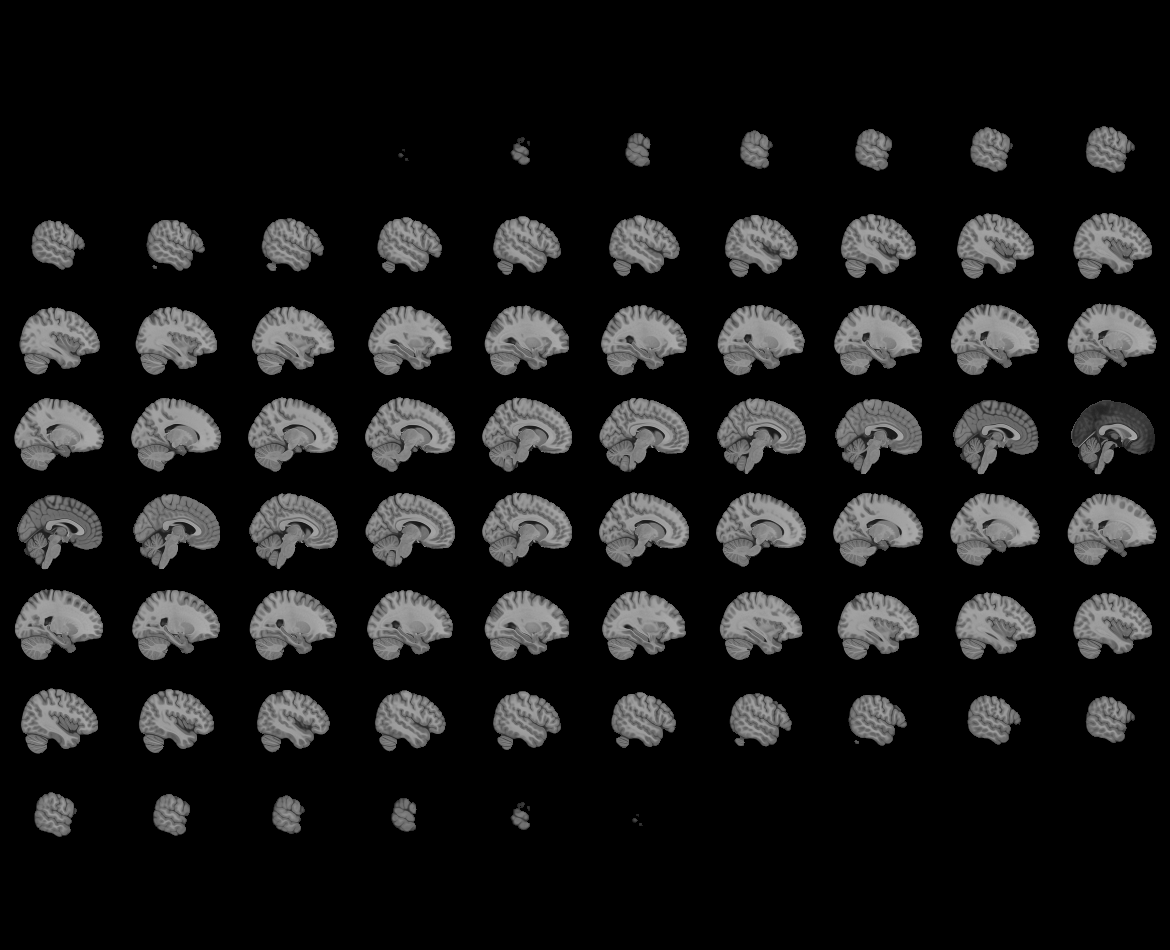
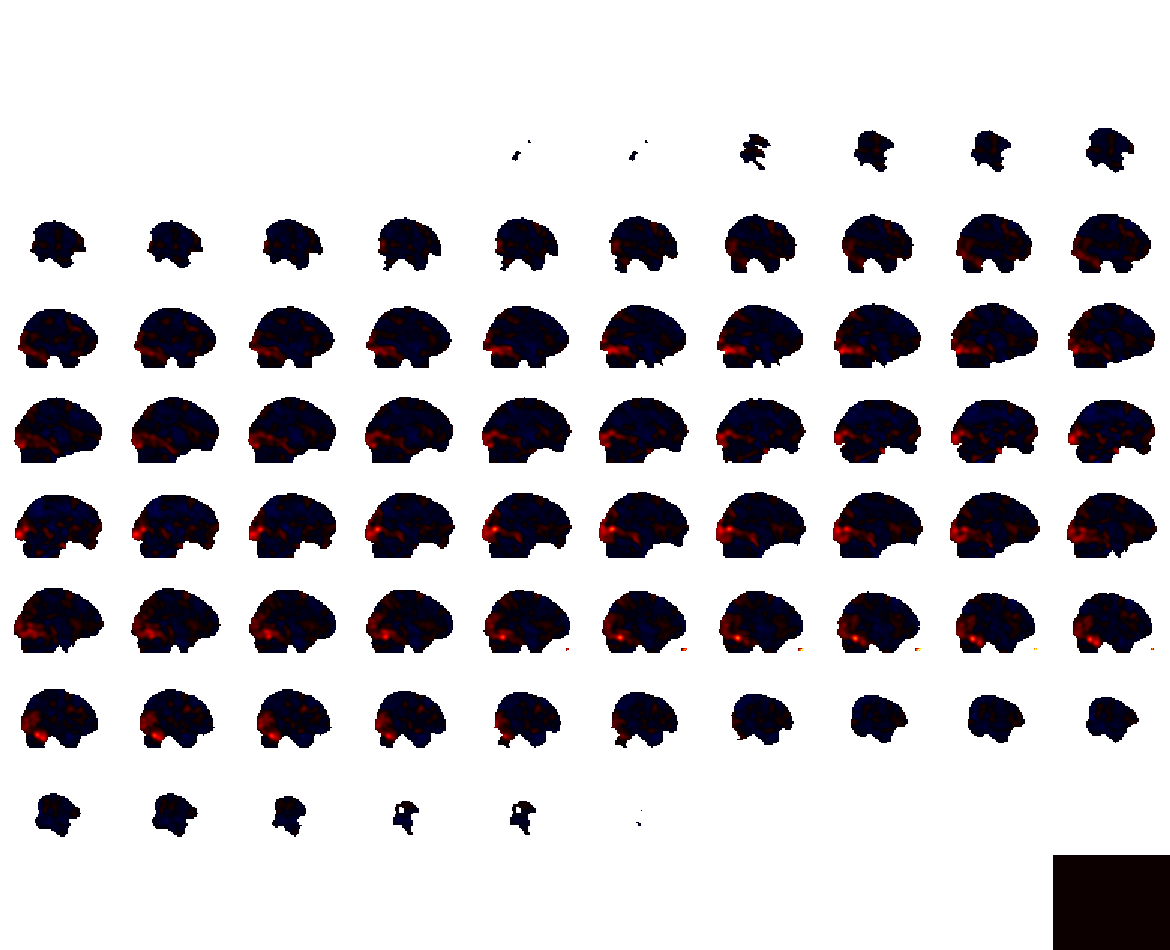

In [19]:
plot_slice = np.array(allsub_avg[10])[1,:]
plot_slice_3d = plot_slice.reshape(53, 63, 46)
plot_neural_rdm_cont1 = new_img_like(tmp_img, plot_slice_3d)
view = plotting.view_img(plot_neural_rdm_cont1)
view

## Load Behavioral RDMs

### Euclidean based behavioral RDM

In [2]:
rdm_behavioral = pd.read_csv("../IAPS_behavioral_RDM/rdm_behavioral_normed.csv", index_col=0)
rdm_behavioral = np.array(rdm_behavioral)


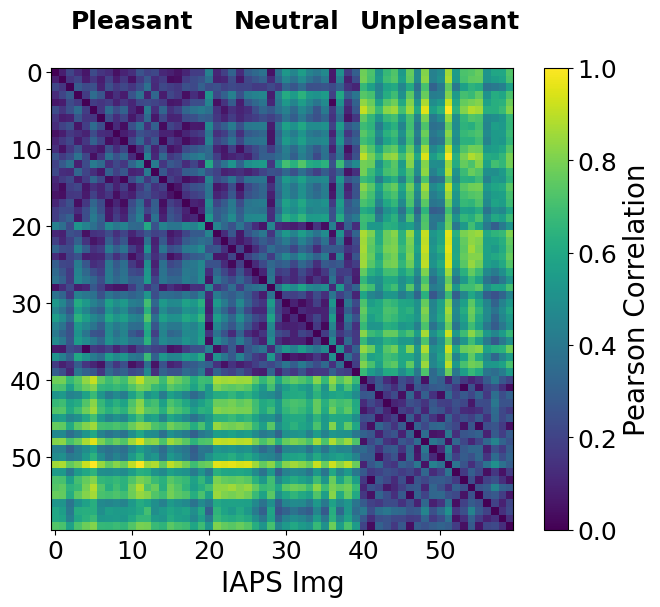

In [28]:
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 6))  # Adjust figure size if needed

# Show image
shw = ax.imshow(rdm_behavioral)

# Add colorbar
bar = plt.colorbar(shw)

# Increase font size
plt.xlabel('IAPS Img', fontsize=20)  # Larger x-axis label
# plt.ylabel('IAPS Img', fontsize=20)  # Larger y-axis label
bar.set_label('Pearson Correlation', fontsize=20)  # Larger colorbar label

# Increase tick label size
ax.tick_params(axis='both', labelsize=18)  # Both x and y ticks
bar.ax.tick_params(labelsize=18)  # Colorbar tick labels

# Define category labels and their positions
category_labels = ['Pleasant', 'Neutral', 'Unpleasant']
tick_positions = [10, 30, 50]  # Midpoints of each category range

# Add category labels on top of the RDM
for pos, label in zip(tick_positions, category_labels):
    ax.text(pos, -5, label, ha='center', va='bottom', fontsize=18, fontweight='bold')

# Show plot
plt.show()


### Correlation based behavioral RDM

### Random "behavioral" RDM

In [141]:
# Creating a 60x60 array with random values from 0 to 10
rdm_behavioral = np.random.randint(0, 11, size=(60, 60))/10

# Setting the diagonal values to 0
np.fill_diagonal(rdm_behavioral, 0)

In [13]:
behavioral_model = ModelFixed('Behavioral RDM', upper_tri(rdm_behavioral))

## Searchlight analysis

### Correlation based nerual RDM

In [144]:
eval_score_list = []
RDM_brain_list = []

for i in range(20):
    subj_data = allsub_avg[i]
    subj_data_2d = np.nan_to_num(subj_data)

    image_value = np.arange(60)
    SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

    eval_results = evaluate_models_searchlight(SL_RDM, behavioral_model, eval_fixed, method='spearman', n_jobs=6)
    # get the evaulation score for each voxel
    # We only have one model, but evaluations returns a list. By using float we just grab the value within that list
    eval_score = [np.float(e.evaluations) for e in eval_results]
    # Create an 3D array, with the size of mask, and
    x, y, z = mask.shape
    RDM_brain = np.zeros([x*y*z])
    RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
    RDM_brain = RDM_brain.reshape([x, y, z])

    eval_score_list.append(eval_score)
    RDM_brain_list.append(RDM_brain)



Evaluating models for each searchlight: 100%|██████████| 56949/56949 [01:42<00:00, 557.15it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_11308\3037220141.py:14: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  eval_score = [np.float(e.evaluations) for e in eval_results]
Evaluating models for each searchlight: 100%|██████████| 56949/56949 [01:12<00:00, 786.71it/s]


### Export searchlight results

In [8]:
voxel_center_id = SL_RDM.rdm_descriptors['voxel_index']
pd.DataFrame(voxel_center_id).to_csv("./outputs/voxel_center_id.csv")

NameError: name 'SL_RDM' is not defined

In [145]:
# Export
# Save the evaluation scores and RDMs.
pd.DataFrame(eval_score_list).to_csv("./outputs/20sub_SL_eval_score_randomrdm_norm.csv")

dbfile= open('./outputs/20sub_SL_rdm_brain_randomrdm_norm', 'ab')
pickle.dump(RDM_brain_list, dbfile)                     
dbfile.close()


### Import searchlight results

In [3]:
# Import
eval_score_list = pd.read_csv("./outputs/searchlight_results/20sub_SL_eval_score_norm_v3.csv", header=0, index_col=0)
dbfile = open('./outputs/20sub_SL_rdm_brain_norm_v3_euc', 'rb')
RDM_brain_list = pickle.load(dbfile)


In [60]:
print(np.array(eval_score_list).shape,'\n')
print(np.array(RDM_brain_list).shape,'\n')


(20, 56949) 

(20, 53, 63, 46) 



In [9]:
voxel_center_id = pd.read_csv("./outputs/voxel_center_id.csv", header=0, index_col=0)

### Plot results

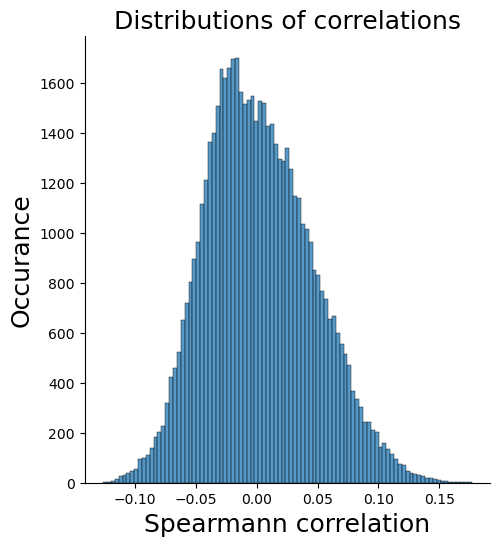

In [18]:
sns.displot(np.array(eval_score_list)[0])
plt.title('Distributions of correlations', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation', size=18)
sns.despine()
plt.show()

## Group analysis
When these results are used for group analysis across multiple subjects, it may be good to Fisher-transform the correlation values, so that they are more normally distributed.


In [5]:
eval_score_array = np.array(eval_score_list)
eval_score_array.shape

(20, 56949)

### Z transformation

##### Fisher Z-Transformation

In [102]:
epsilon = 1e-10  # Small value to avoid division by zero
eval_score_array = np.clip(eval_score_array, -1 + epsilon, 1 - epsilon)
fisher_z_array = 0.5 * np.log((1 + eval_score_array) / (1 - eval_score_array))


c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



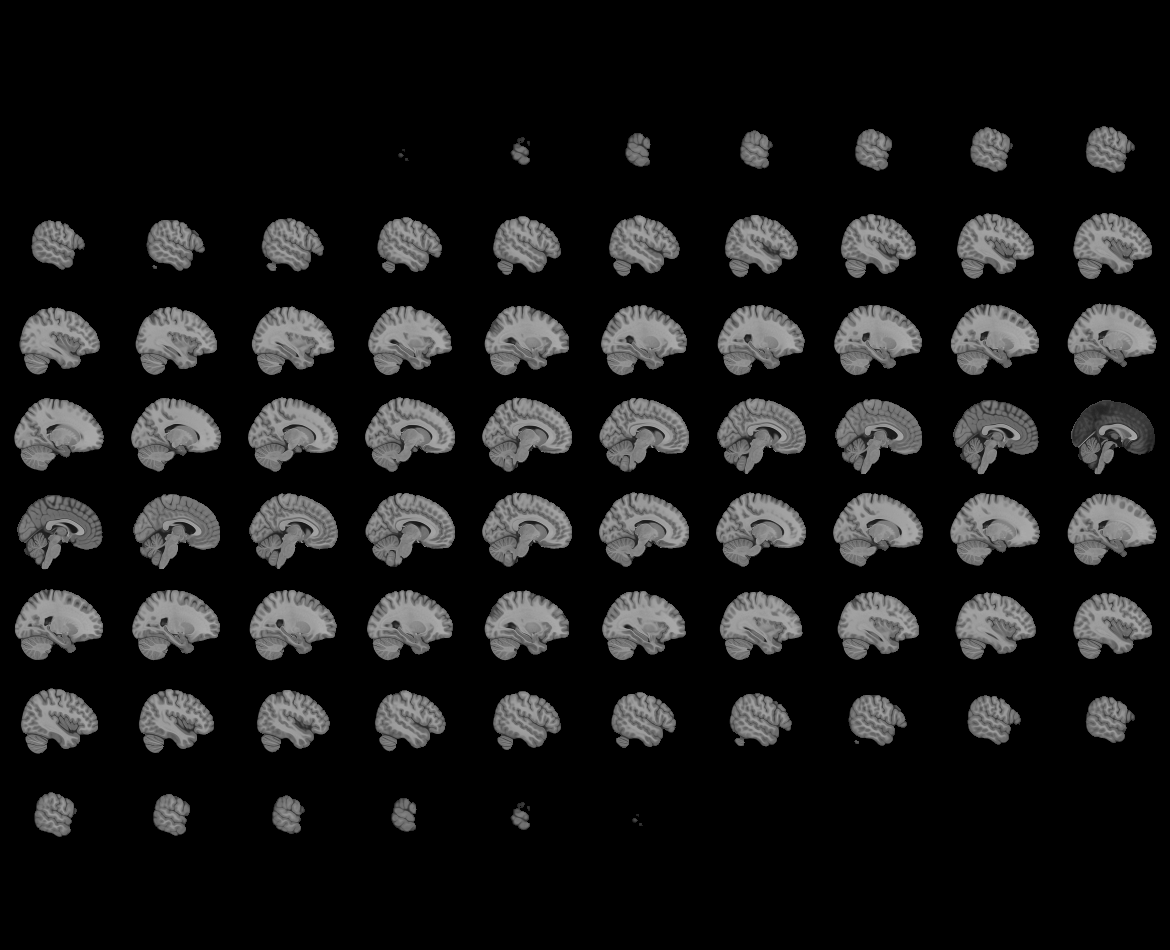
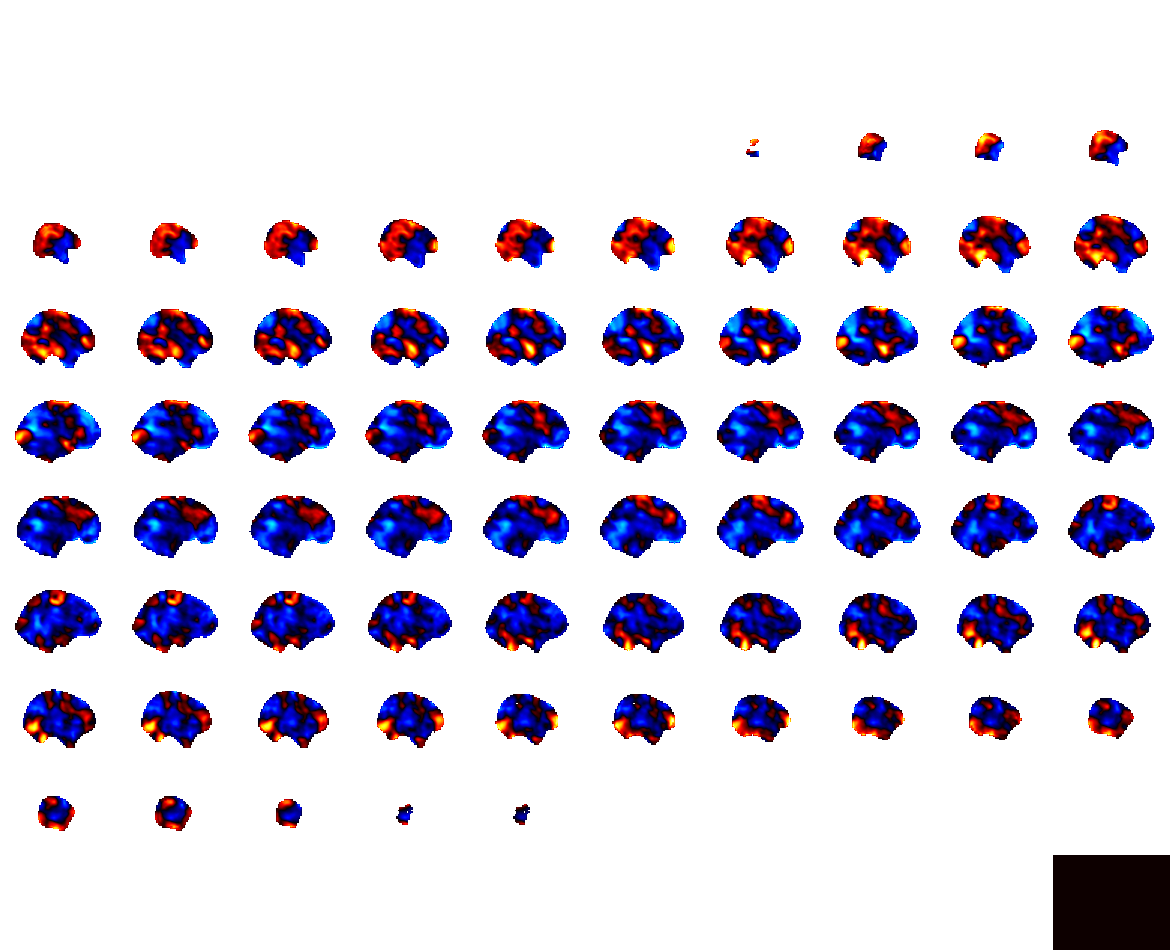

In [78]:
# x, y, z = 53,63,46
# corr_fisher_z = np.empty([x*y*z])
# corr_fisher_z[list(SL_RDM.rdm_descriptors['voxel_index'])] = z_arr[19]
# corr_fisher_z_3d = corr_fisher_z.reshape([x, y, z])
# corr_fisher_brain = new_img_like(tmp_img, corr_fisher_z_3d)
# view = plotting.view_img(corr_fisher_brain)
# view

#### Standard Z-Transformation

In [87]:
# # Z-transformation along the second dimension (standardize each row)
# mean_row = eval_score_array.mean(axis=1, keepdims=True)
# std_row = eval_score_array.std(axis=1, keepdims=True)
# z_arr = (eval_score_array - mean_row) / std_row

# # # Z-transformation along the first dimension (standardize each column)
# # mean_col = arr_standardized_rows.mean(axis=0, keepdims=True)
# # std_col = arr_standardized_rows.std(axis=0, keepdims=True)
# # z_arr = (arr_standardized_rows - mean_col) / std_col

### Threshold correlation

In [98]:
# z_arr[(z_arr < 0.1) & (z_arr > -0.1) ] = 0

### Group level t-test

In [99]:
t_stat_list = []
p_value_list = []

for i in range(z_arr.shape[-1]): #loop thru center voxels
    t_statistic, p_value = stats.ttest_1samp(a=z_arr[:,i], popmean=0) 
    t_stat_list.append(t_statistic)
    p_value_list.append(p_value)

t_stat_array = np.array(t_stat_list)
p_value_array = np.array(p_value_list)

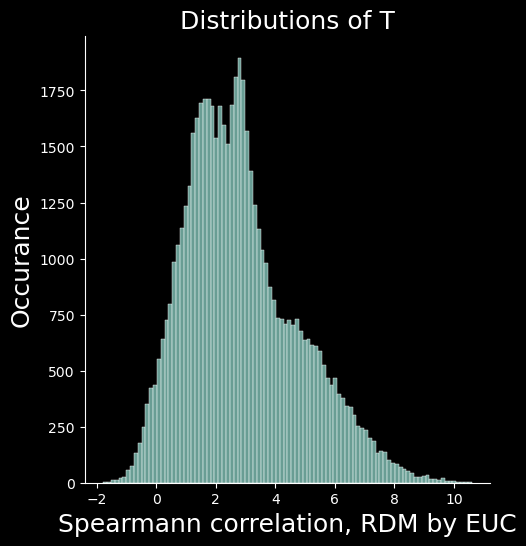

In [36]:
sns.displot(t_stat_array)
plt.title('Distributions of T', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation, RDM by EUC', size=18)
sns.despine()
plt.show()

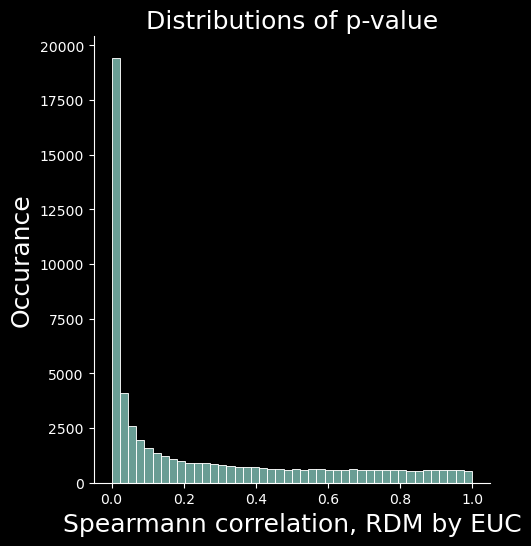

In [69]:
sns.displot(p_value_array)
plt.title('Distributions of p-value', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('Spearmann correlation, RDM by EUC', size=18)
sns.despine()
plt.show()

### Corrected p-values

In [65]:
subj_data = allsub_avg[1]
subj_data_2d = np.nan_to_num(subj_data)

image_value = np.arange(60)
SL_RDM = get_searchlight_RDMs(subj_data_2d, centers, neighbors, image_value, method='correlation')

NameError: name 'centers' is not defined

In [21]:
SL_RDM_file= open('./SL_RDM', 'ab')
pickle.dump(SL_RDM, SL_RDM_file)                  
SL_RDM_file.close()

In [66]:
# Open the file in binary read mode
with open('./SL_RDM', 'rb') as SL_RDM_file:
    SL_RDM = pickle.load(SL_RDM_file)


In [100]:
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.05, method='indep', is_sorted=False)
sig_voxel = np.where(corrected_pvalue<0.05)
# sig_voxel = np.where(reject_decision)[0]

x, y, z = 53,63,46
# t_stat_sig = np.full(([x*y*z]), np.nan)
t_stat_sig = np.full((x*y*z), np.nan)
t_stat_sig[np.array(SL_RDM.rdm_descriptors['voxel_index'])[sig_voxel]] = t_stat_array[sig_voxel]

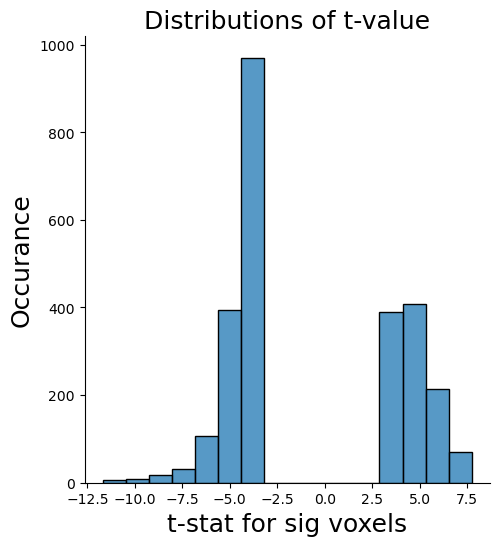

In [86]:
sns.displot(t_stat_array[sig_voxel])
plt.title('Distributions of t-value', size=18)
plt.ylabel('Occurance', size=18)
plt.xlabel('t-stat for sig voxels', size=18)
sns.despine()
plt.show()

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\_utils\niimg.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  warn(



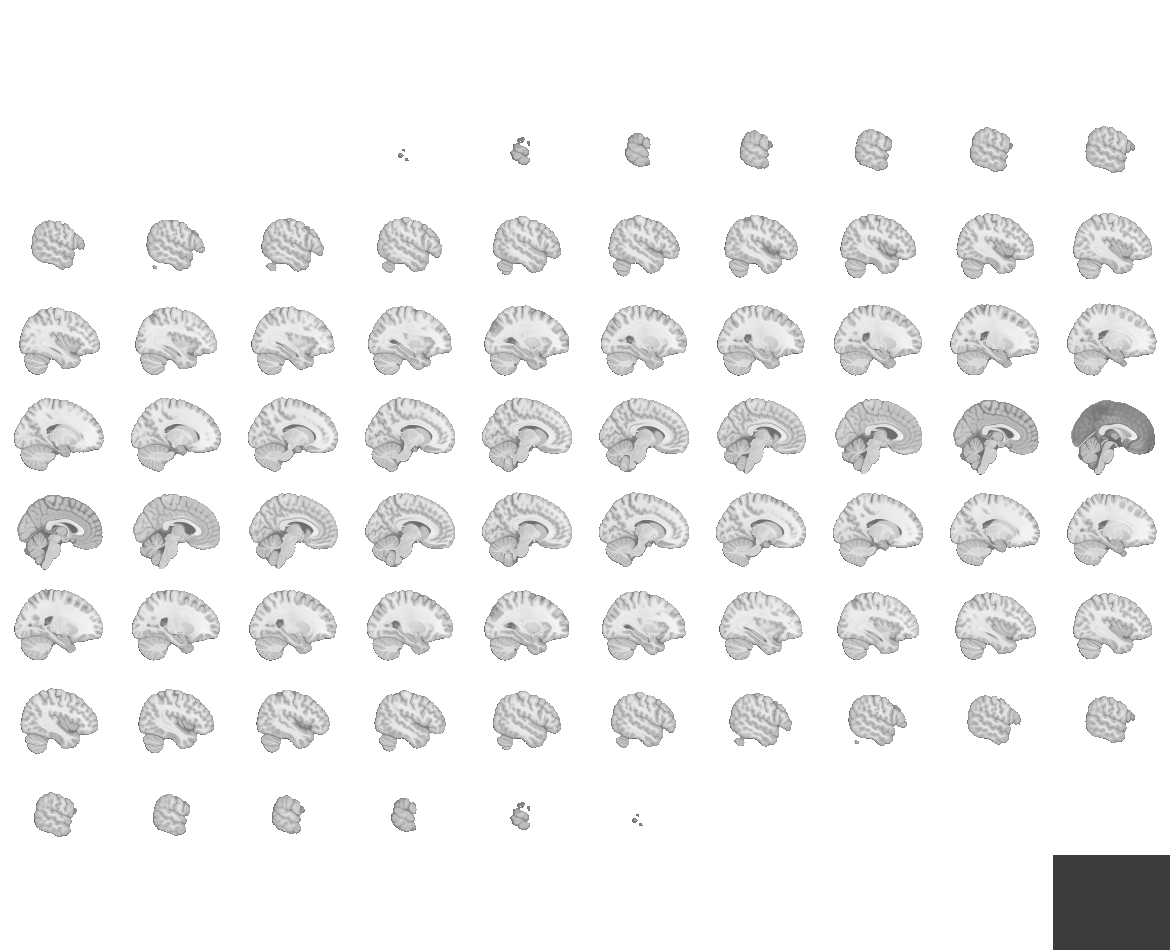
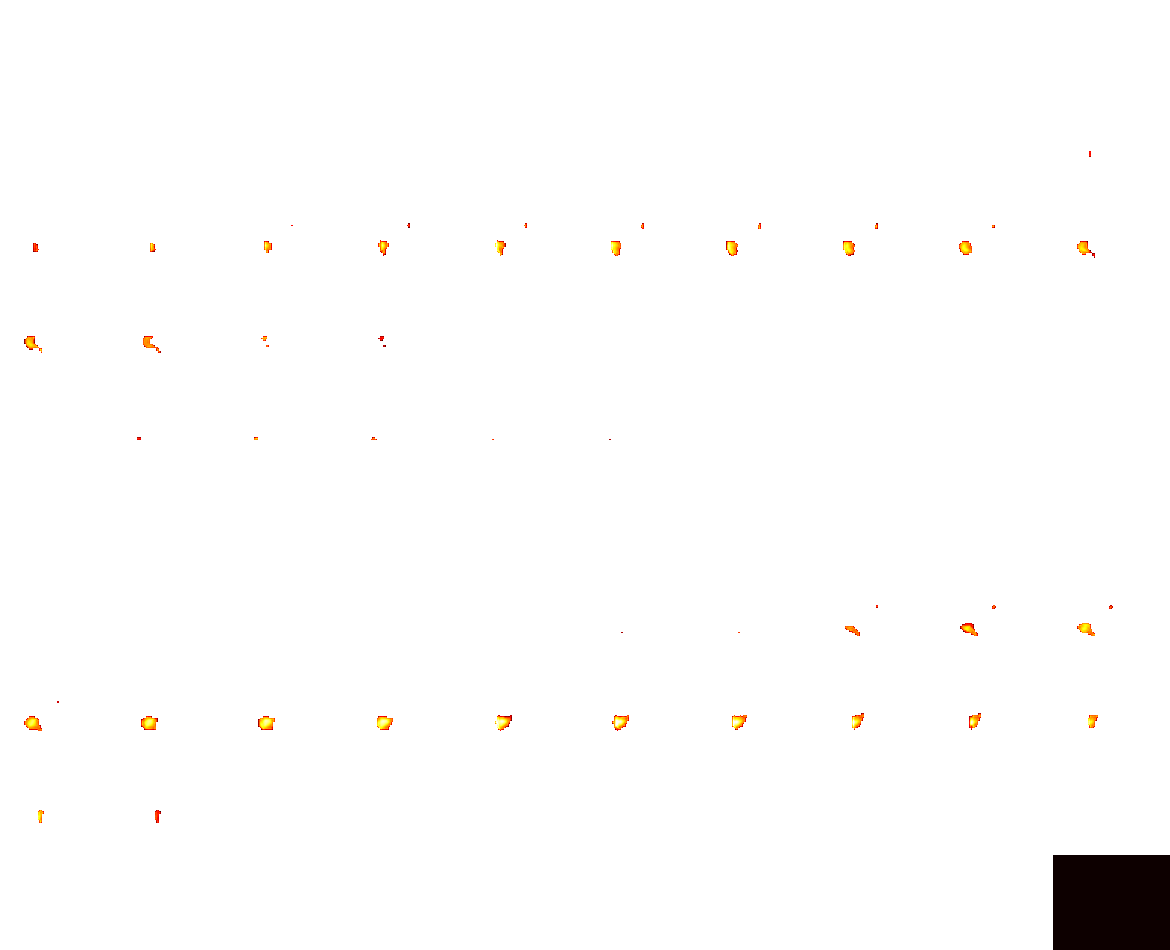

In [41]:
t_stat_sig_3d = t_stat_sig.reshape([x, y, z])
# Set t-values less than 0 to NaN (or you could set it to 0 if you prefer)
t_stat_sig_3d[t_stat_sig_3d < 0] = np.nan

# Create a new image object from the modified t-statistic data
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)
view = plotting.view_img(t_stat_sig_img, draw_cross = False, 
                         black_bg = False, threshold=0)
view

### Set cluster thresholding

In [96]:
t_stat_sig_img_clsuter = nlimg.threshold_img(t_stat_sig_img, 0, cluster_threshold=10)

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\nilearn\image\image.py:939: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


In [ ]:
view = plotting.view_img(t_stat_sig_img_clsuter)
view

Based on Correlation fMRI RDM

c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\numpy\core\fromnumeric.py:758: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)
c:\Users\yujunchen\Anaconda3\envs\neuro\lib\site-packages\nilearn\plotting\html_document.py:59: UserWarning: It seems you have created more than 10 nilearn views. As each view uses dozens of megabytes of RAM, you might want to delete some of them.
  warnings.warn('It seems you have created more than {} '



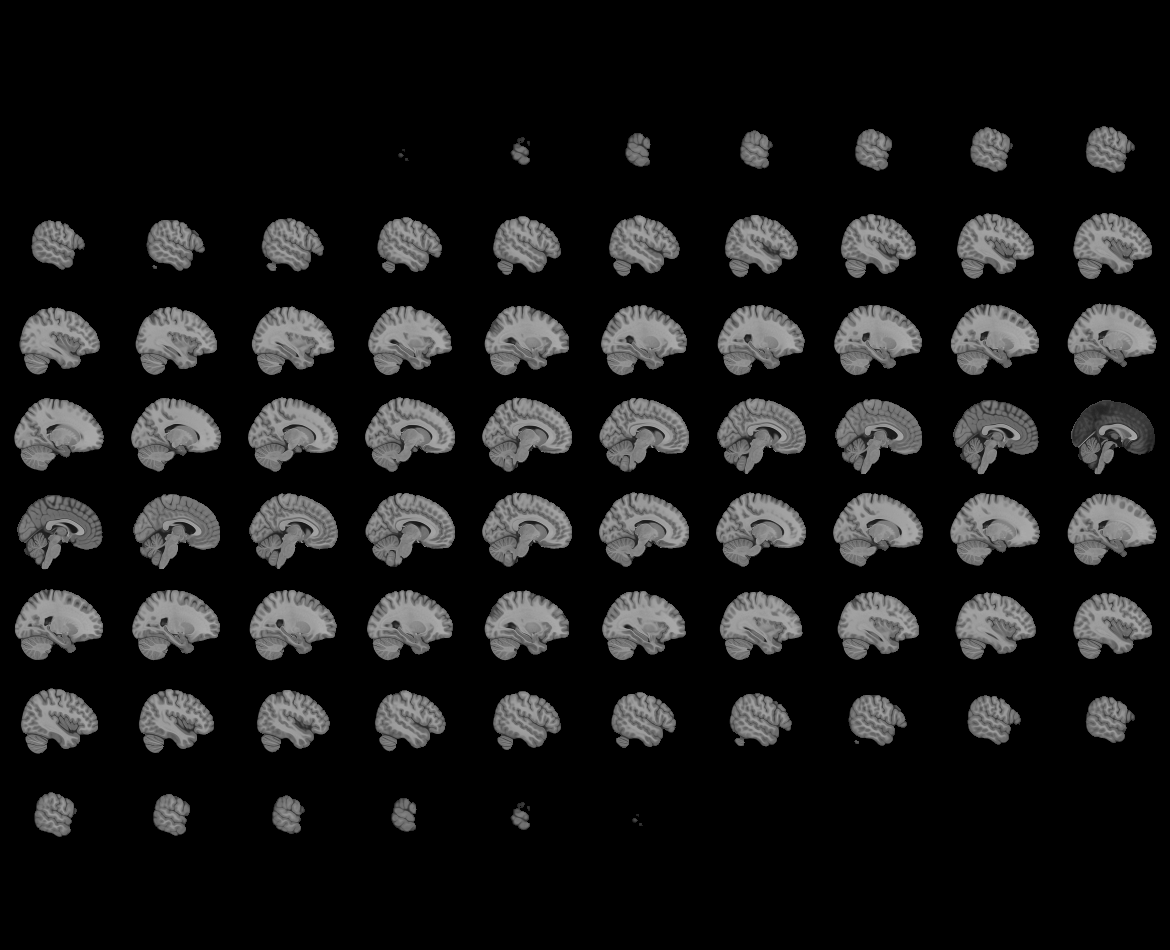
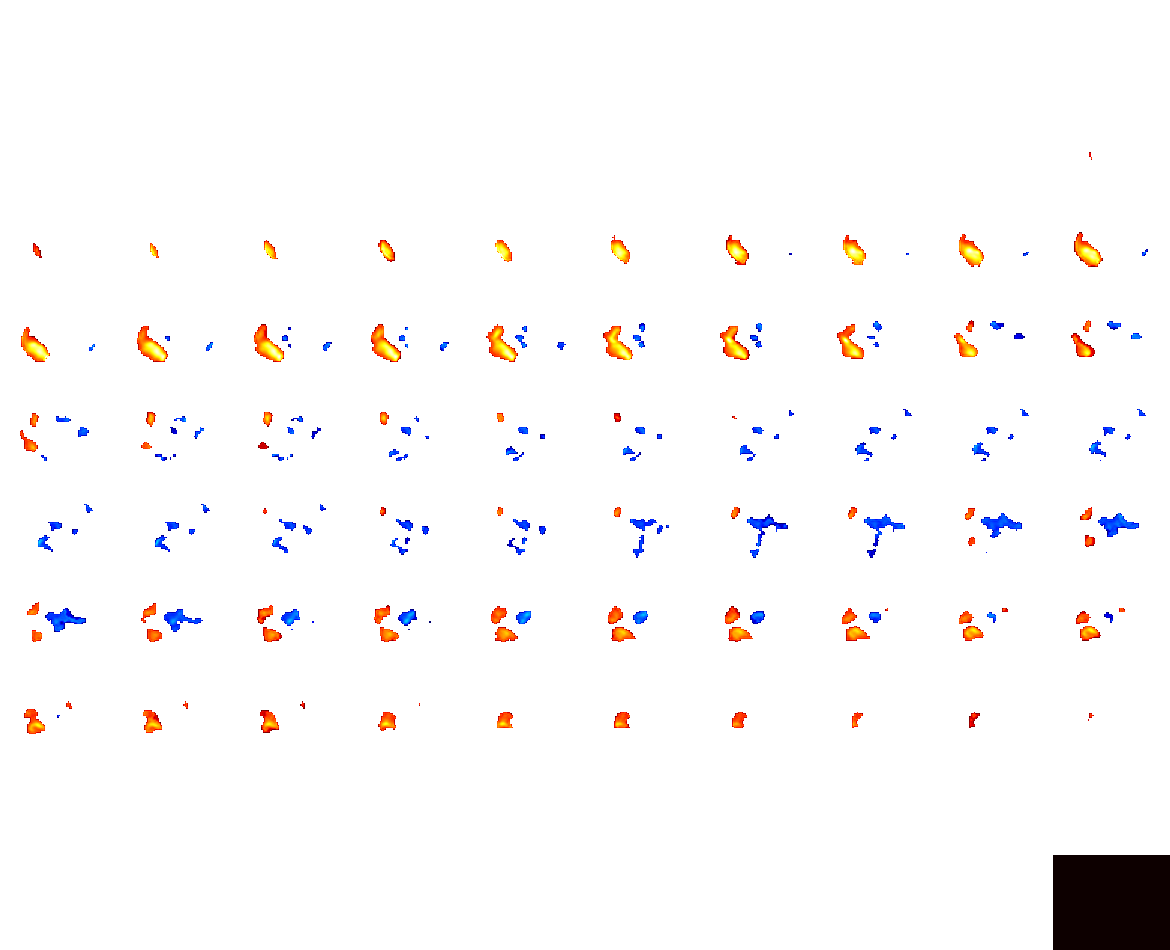

In [100]:
view = plotting.view_img(t_stat_sig_img_clsuter)
view

### All in one analysis

In [ ]:
from scipy.stats import ttest_1samp

# 1. Apply Fisher's transformation to the correlation coefficients
# fisher_z_scores = 0.5 * np.log((1 + eval_score_array) / (1 - eval_score_array))

eval_score_array = np.array(eval_score_list)
fisher_z_scores = np.arctanh(eval_score_array)

# 2. Perform t-tests voxel by voxel across subjects
t_stat_array, p_value_array = ttest_1samp(fisher_z_scores, 0, axis=0)

# 3. Apply FDR correction to p-values
reject_decision, corrected_pvalue = fdrcorrection(p_value_array, alpha=0.01, method='indep')

# 4. Select significant voxels based on the corrected p-values
sig_voxel = np.where(corrected_pvalue < 0.01)[0]

# Dimensions of the voxel space (x, y, z = 53, 63, 46)
x, y, z = 53, 63, 46

# Initialize an array for the t-statistics in 3D space
t_stat_sig = np.full((x * y * z), np.nan)

# Assign t-statistics to significant voxels
t_stat_sig[np.squeeze(np.array(voxel_center_id))[sig_voxel]] = t_stat_array[sig_voxel]

# Reshape the 1D t-statistics array into a 3D array matching the voxel space
t_stat_sig_3d = t_stat_sig.reshape([x, y, z])

# Set t-values less than 0 to NaN if you prefer not to show negative values
t_stat_sig_3d[t_stat_sig_3d < 0] = np.nan

# 5. Create a new image object from the 3D t-statistics
t_stat_sig_img = new_img_like(tmp_img, t_stat_sig_3d)

# 6. Apply cluster thresholding (optional)
t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)



C:\Users\yujunchen\AppData\Local\Temp\ipykernel_25212\2756708807.py:37: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_stat_sig_img_cluster = nlimg.threshold_img(t_stat_sig_img, threshold=0, cluster_threshold=30)
c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\nilearn\image\image.py:997: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  img_data = safe_get_data(img, ensure_finite=True, copy_data=copy)


c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro161\lib\site-packages\numpy\_core\fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



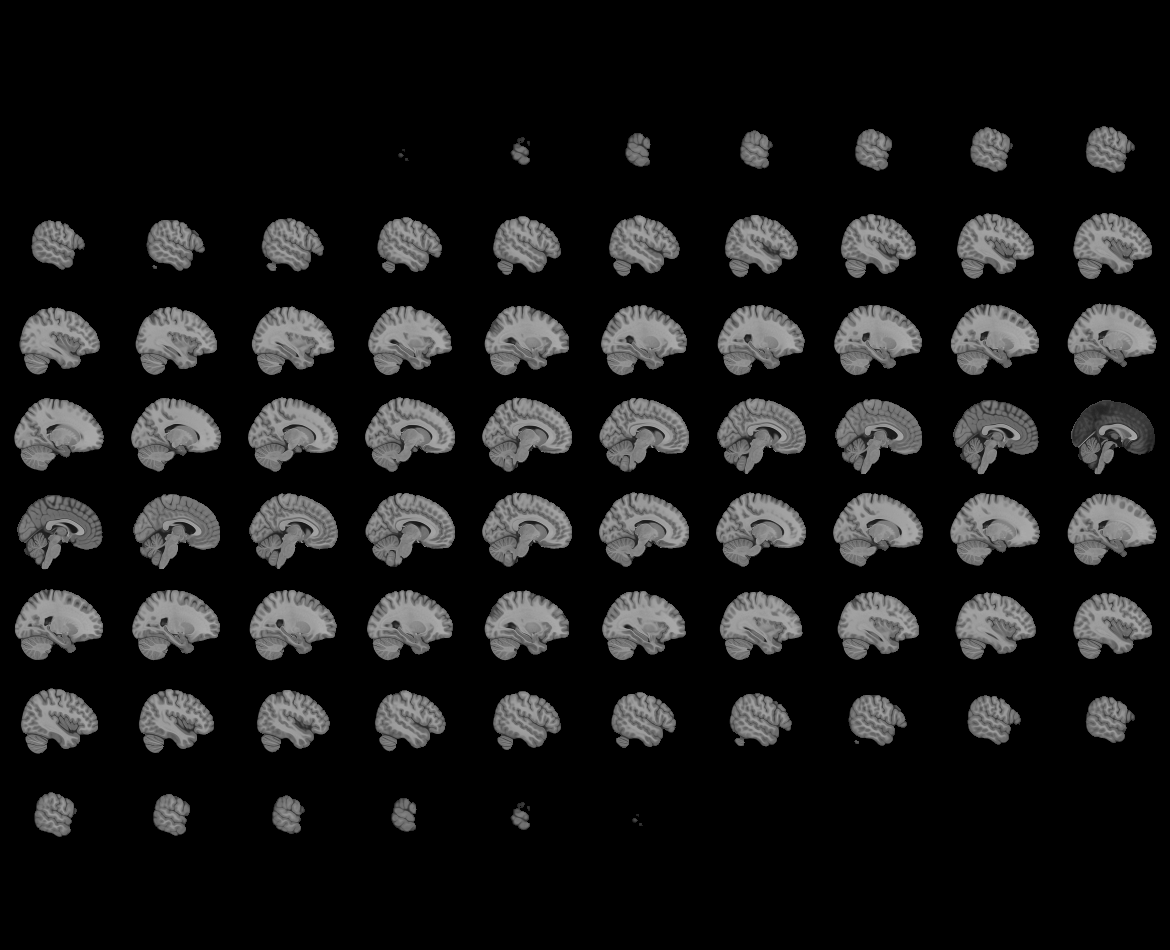
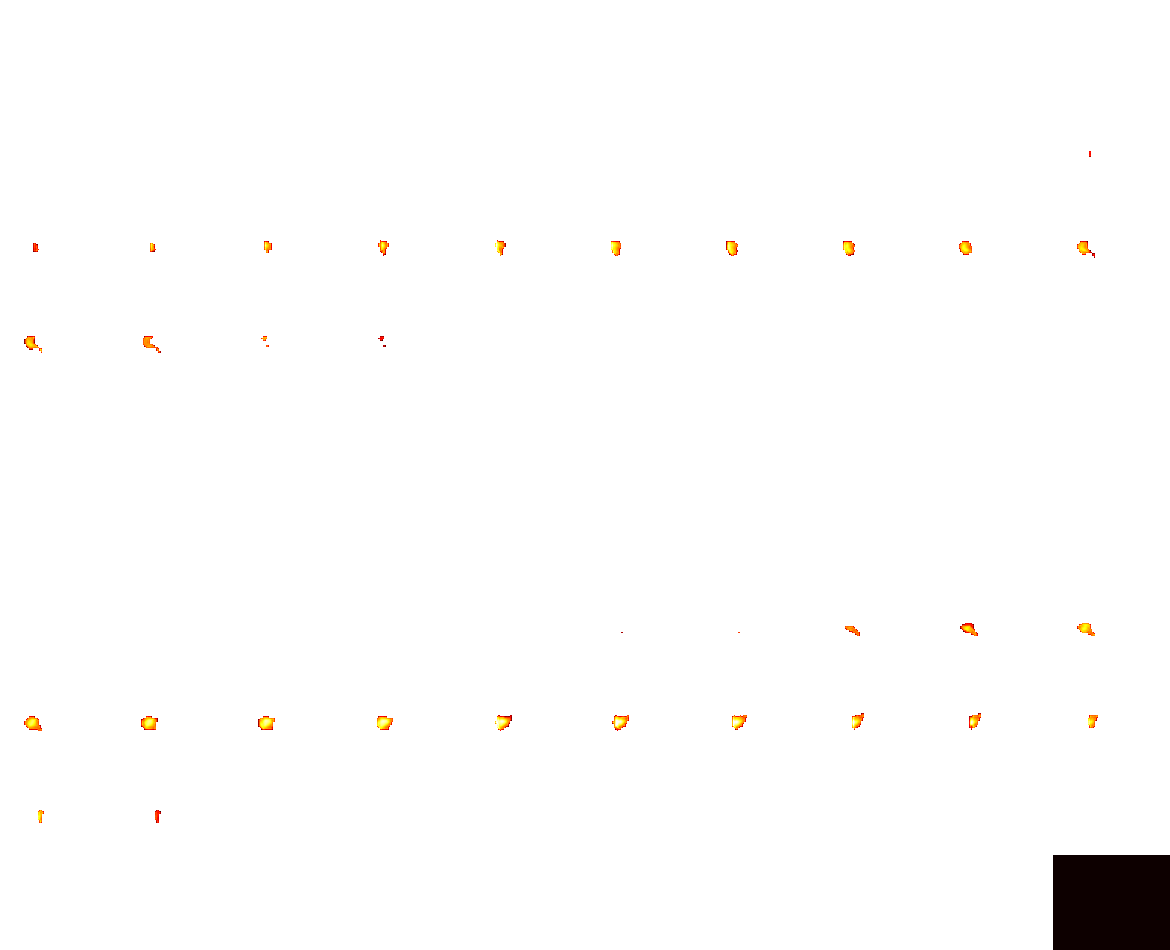

In [32]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view


Results:
- t_stat_sig_img
- plot_corrected_neglog_pvalue_img

In [115]:
# nib.save(t_stat_sig_img_clsuter, os.path.join("./outputs/tBrainmap", 'tmap_beh60_p001_random.nii.gz'))
nib.save(t_stat_sig_img_cluster, os.path.join("./outputs/tBrainmap", 'tmap_beh60_p05_v3_fisherz.nii.gz'))


In [163]:
nib.save(t_stat_sig_img_cluster, os.path.join("C:/Users/yujunchen/OneDrive - University of Florida/Searchlight results", 'tmap_beh60_p05_v3_fisherz.nii.gz'))

In [7]:
t_stat_sig_img_cluster = nib.load(os.path.join("./outputs/tBrainmap", 'tmap_beh60_p05_v3_fisherz.nii.gz'))

c:\Users\yujunchen\Anaconda3\envs\neuro_local\lib\site-packages\numpy\core\fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



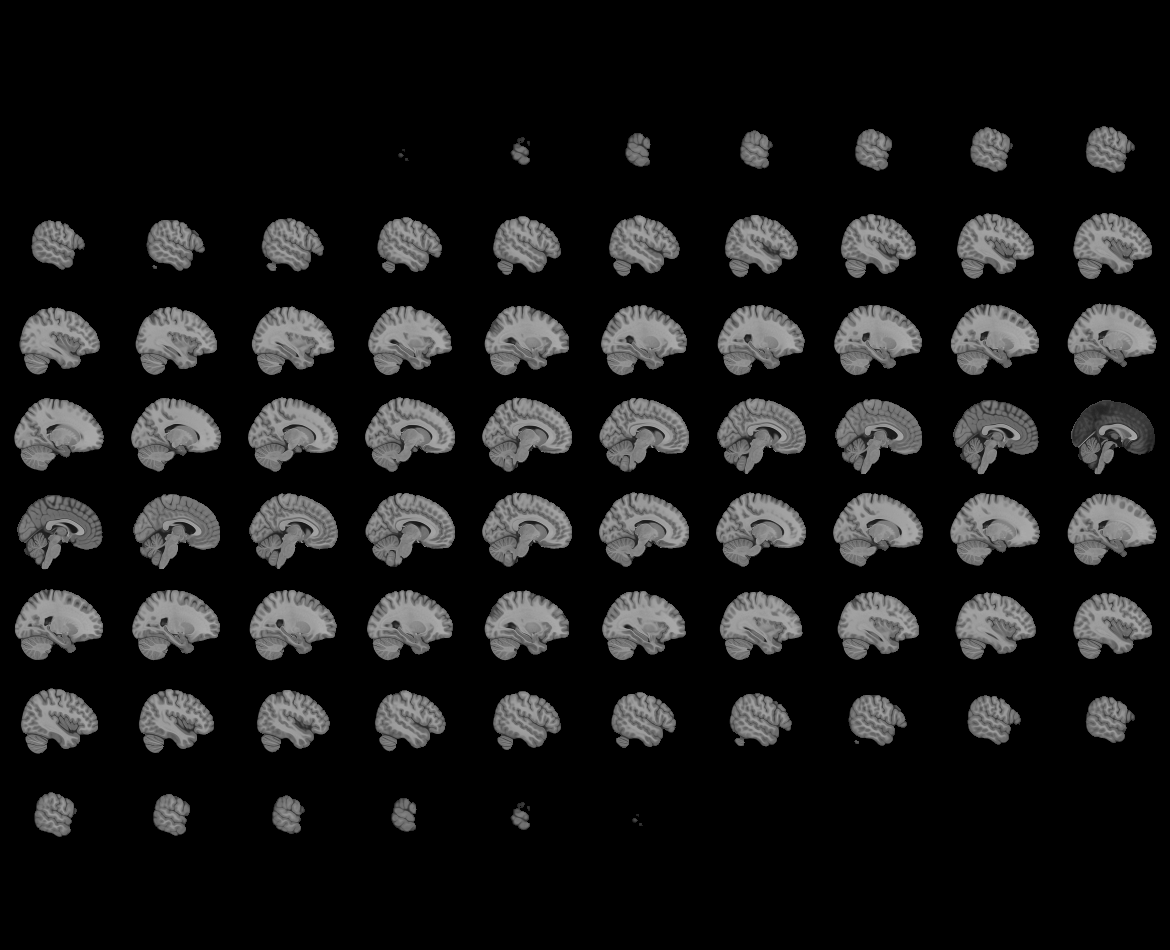
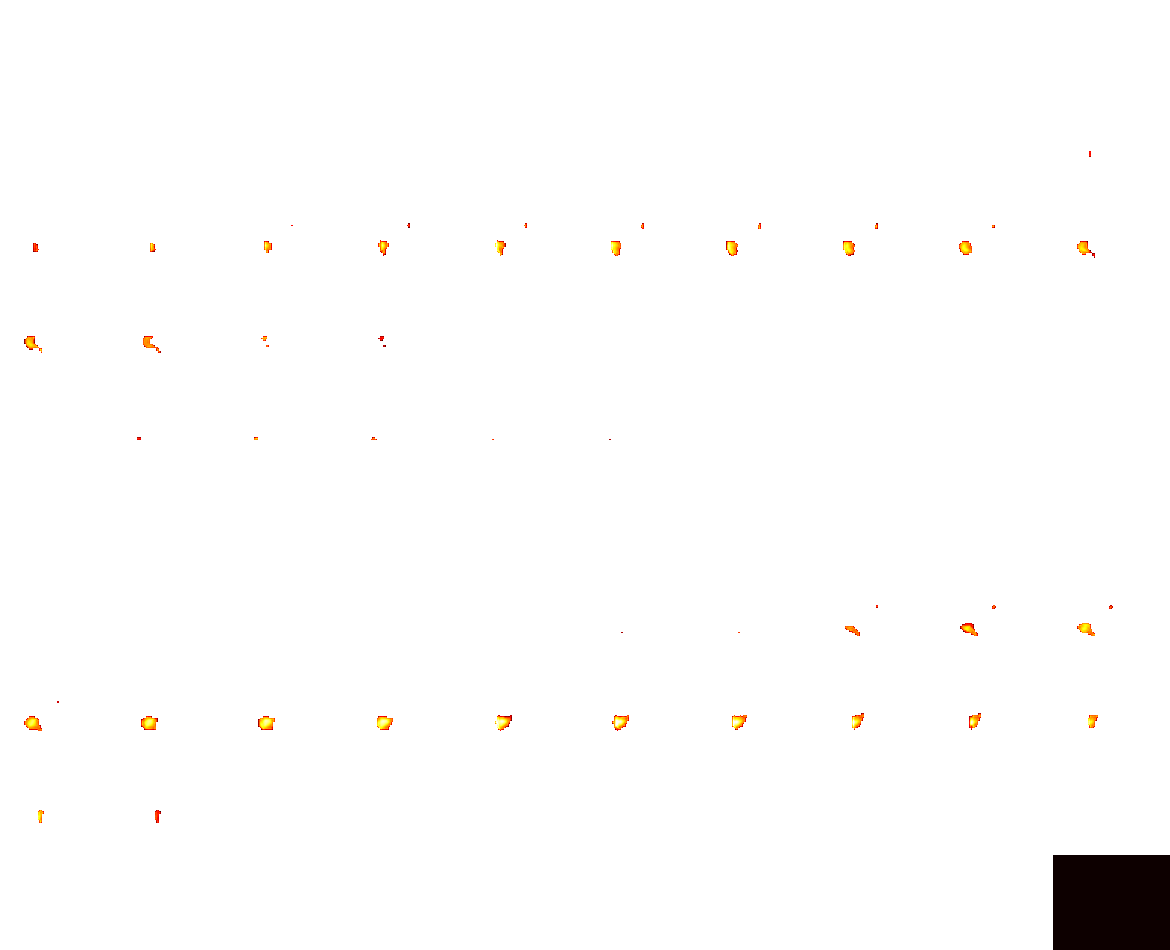

In [8]:
# 7. Visualize the significant voxel centers
view = plotting.view_img(t_stat_sig_img_cluster)
view